In [86]:
import numpy as np
import matplotlib.pyplot as plt
import math

elev = 25
azim = -60
arrow_scale = 0.15
seg_colors = ['#d62728', '#ff7f0e', '#9467bd']

def plot_scene(ax, segments, touchdown_point, bellmouth,
               V_wave=None, show_velocities=True, show_forces=False, show_moments=False,
               M_touchdown=None, M_bellmouth=None):
    all_points = np.array([seg['start'] for seg in segments] + [segments[-1]['end']])
    x_range = [all_points[:,0].min() - 0.5, all_points[:,0].max() + 0.5]
    z_range = [0, all_points[:,2].max() + 0.5]
    
    ax.plot3D([x_range[0], x_range[1]], [0, 0], [0, 0], 'k-', linewidth=0.5, alpha=0.3)
    ax.plot3D([0, 0], [-1, 1], [0, 0], 'k-', linewidth=0.5, alpha=0.3)
    ax.plot3D([0, 0], [0, 0], [0, z_range[1]], 'k-', linewidth=0.5, alpha=0.3)
    
    for seg in segments:
        color = seg_colors[(seg['index'] - 1) % len(seg_colors)]
        ax.plot3D([seg['start'][0], seg['end'][0]],
                  [seg['start'][1], seg['end'][1]],
                  [seg['start'][2], seg['end'][2]],
                  '-', color=color, linewidth=4, solid_capstyle='round',
                  label=f"Seg {seg['index']} (θ={seg['theta_vert']}°)")
    
    ax.scatter(*touchdown_point, color='black', s=80, marker='s', zorder=5, label='Touchdown')
    ax.scatter(*bellmouth, color='black', s=80, marker='^', zorder=5, label='Bellmouth')
    
    if show_velocities and V_wave is not None and 'V_normal' in segments[0]:
        for i, seg in enumerate(segments):
            if i == 0:
                ax.quiver(*seg['midpoint'], *V_wave, color='blue',
                          arrow_length_ratio=arrow_scale, linewidth=2, label='V_wave')
            if 'V_parallel' in seg:
                ax.quiver(*seg['midpoint'], *seg['V_parallel'], color='orange',
                          arrow_length_ratio=arrow_scale, linewidth=1.5,
                          label='V_parallel' if i == 0 else '')
            ax.quiver(*seg['midpoint'], *seg['V_normal'], color='cyan',
                      arrow_length_ratio=arrow_scale, linewidth=1.5,
                      label='V_normal' if i == 0 else '')
    
    if show_forces and 'F_drag' in segments[0]:
        F_max = max(np.linalg.norm(seg['F_drag']) for seg in segments)
        F_scale = 0.3 / F_max if F_max > 0 else 1
        for i, seg in enumerate(segments):
            ax.quiver(*seg['midpoint'], *(seg['F_drag'] * F_scale), color='green',
                      arrow_length_ratio=arrow_scale, linewidth=2,
                      label=f'F_drag (scaled)' if i == 0 else '')
    
    if show_moments and M_touchdown is not None and M_bellmouth is not None:
        M_max = max(np.linalg.norm(M_touchdown), np.linalg.norm(M_bellmouth))
        M_scale = 0.4 / M_max if M_max > 0 else 1
        ax.quiver(*touchdown_point, *(M_touchdown * M_scale), color='magenta',
                  arrow_length_ratio=arrow_scale, linewidth=2, label='M (scaled)')
        ax.quiver(*bellmouth, *(M_bellmouth * M_scale), color='magenta',
                  arrow_length_ratio=arrow_scale, linewidth=2)
    
    ax.set_xlabel('x (East)')
    ax.set_ylabel('y (North)')
    ax.set_zlabel('z (Up)')
    ax.set_box_aspect([1, 1, 1])

In [87]:
# === Parameters matching fls_proxy_ff.py ===
# Physical properties
D = 0.251           # CPS outer diameter [m] (from fls_proxy_ff.py)
rho = 1025          # seawater density [kg/m³]
Cd = 1.2            # drag coefficient

# Wave kinematics (dummy values for testing)
theta_wave = 180    # wave direction [deg from N, 'going to' convention]
u_w = 0.7           # wave orbital velocity magnitude [m/s]
Tp = 8.0            # wave period [s]

# Current (dummy, collinear with wave for testing)
theta_current = 90 # current direction [deg from N] - same as wave
u_c = 0.2           # current velocity magnitude [m/s]

# CPS heading
theta_heading = 90   # CPS heading [deg from N]

# CPS segment definition (from TOUCHDOWN to BELLMOUTH)
segments_def = [
    [1, 10],   # Seg 1: near touchdown (almost horizontal)
    [1, 45],   # Seg 2: middle transition  
    [1, 60],   # Seg 3: near bellmouth (steeper)
]

# Touchdown point location
touchdown_point = np.array([3.0, 0.0, 0.0])

print(f"=== Parameters (matching fls_proxy_ff.py) ===")
print(f"D = {D} m, rho = {rho} kg/m³, Cd = {Cd}")
print(f"Wave: u_w = {u_w} m/s, dir = {theta_wave}°, Tp = {Tp} s")
print(f"Current: u_c = {u_c} m/s, dir = {theta_current}° (collinear)")

=== Parameters (matching fls_proxy_ff.py) ===
D = 0.251 m, rho = 1025 kg/m³, Cd = 1.2
Wave: u_w = 0.7 m/s, dir = 180°, Tp = 8.0 s
Current: u_c = 0.2 m/s, dir = 90° (collinear)


In [88]:
# Wave and Current direction vectors (horizontal plane)
wave_dir_vec = np.array([math.sin(math.radians(theta_wave)),
                         math.cos(math.radians(theta_wave)), 0])
curr_dir_vec = np.array([math.sin(math.radians(theta_current)),
                         math.cos(math.radians(theta_current)), 0])

# Full velocity vectors
V_wave = u_w * wave_dir_vec
V_curr = u_c * curr_dir_vec

print(f"Wave dir vec: {np.round(wave_dir_vec, 3)}")
print(f"Curr dir vec: {np.round(curr_dir_vec, 3)}")
print(f"\nV_wave = {np.round(V_wave, 3)} m/s  (|V| = {u_w:.2f})")
print(f"V_curr = {np.round(V_curr, 3)} m/s  (|V| = {u_c:.2f})")
print(f"\nCrest:  V_total = +V_wave + V_curr = {np.round(V_wave + V_curr, 3)}")
print(f"Trough: V_total = -V_wave + V_curr = {np.round(-V_wave + V_curr, 3)}")

Wave dir vec: [ 0. -1.  0.]
Curr dir vec: [1. 0. 0.]

V_wave = [ 0.  -0.7  0. ] m/s  (|V| = 0.70)
V_curr = [0.2 0.  0. ] m/s  (|V| = 0.20)

Crest:  V_total = +V_wave + V_curr = [ 0.2 -0.7  0. ]
Trough: V_total = -V_wave + V_curr = [0.2 0.7 0. ]


In [89]:
# CPS segments definition
segments = []
current_point = touchdown_point.copy()

for i, (length, theta_vert) in enumerate(segments_def):
    # Segment direction vector (pointing from touchdown toward bellmouth)
    # Negative horizontal component because we go "inward" toward the platform
    seg_axis = np.array([
        -math.cos(math.radians(theta_vert)) * math.sin(math.radians(theta_heading)),
        -math.cos(math.radians(theta_vert)) * math.cos(math.radians(theta_heading)),
         math.sin(math.radians(theta_vert))
    ])
    
    start = current_point.copy()
    end = start + length * seg_axis
    midpoint = (start + end) / 2
    
    segments.append({
        'index': i + 1,
        'length': length,
        'theta_vert': theta_vert,
        'axis': seg_axis,
        'start': start,
        'end': end,
        'midpoint': midpoint
    })
    
    current_point = end.copy()

# Fixed points
bellmouth = segments[-1]['end']

# output CPS segment details as table
for seg in segments:
    print(f"Segment {seg['index']}: θ_vert={seg['theta_vert']}°, L={seg['length']}m")
    print(f"  start: {np.round(seg['start'], 2)}")
    print(f"  end:   {np.round(seg['end'], 2)}")

print(f"Touchdown point: {touchdown_point}")
print(f"Bellmouth point: {np.round(bellmouth, 2)}")

Segment 1: θ_vert=10°, L=1m
  start: [3. 0. 0.]
  end:   [ 2.02 -0.    0.17]
Segment 2: θ_vert=45°, L=1m
  start: [ 2.02 -0.    0.17]
  end:   [ 1.31 -0.    0.88]
Segment 3: θ_vert=60°, L=1m
  start: [ 1.31 -0.    0.88]
  end:   [ 0.81 -0.    1.75]
Touchdown point: [3. 0. 0.]
Bellmouth point: [ 0.81 -0.    1.75]


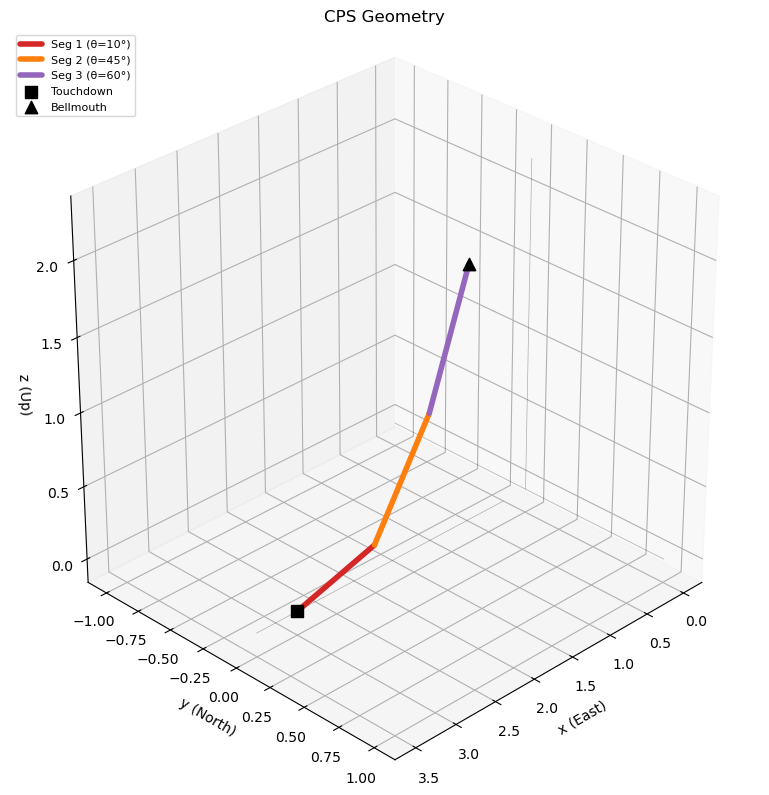

In [90]:
# CPS geometry
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')
plot_scene(ax, segments, touchdown_point, bellmouth)
ax.view_init(elev=30, azim=45)
ax.set_title('CPS Geometry')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [91]:
# Velocity decomposition per segment (using crest state: +V_wave + V_curr)
V_total_crest = V_wave + V_curr

for seg in segments:
    V_par_scalar = np.dot(V_total_crest, seg['axis'])
    V_par = V_par_scalar * seg['axis']
    V_norm = V_total_crest - V_par
    
    seg['V_parallel'] = V_par
    seg['V_normal'] = V_norm
    seg['V_normal_mag'] = np.linalg.norm(V_norm)

print(f"Crest state: V_total = V_wave + V_curr = {np.round(V_total_crest, 3)}")
print(f"|V_total| = {np.linalg.norm(V_total_crest):.3f} m/s\n")
for seg in segments:
    print(f"Seg {seg['index']} (θ={seg['theta_vert']}°): |V_normal| = {seg['V_normal_mag']:.4f} m/s")

Crest state: V_total = V_wave + V_curr = [ 0.2 -0.7  0. ]
|V_total| = 0.728 m/s

Seg 1 (θ=10°): |V_normal| = 0.7009 m/s
Seg 2 (θ=45°): |V_normal| = 0.7141 m/s
Seg 3 (θ=60°): |V_normal| = 0.7211 m/s


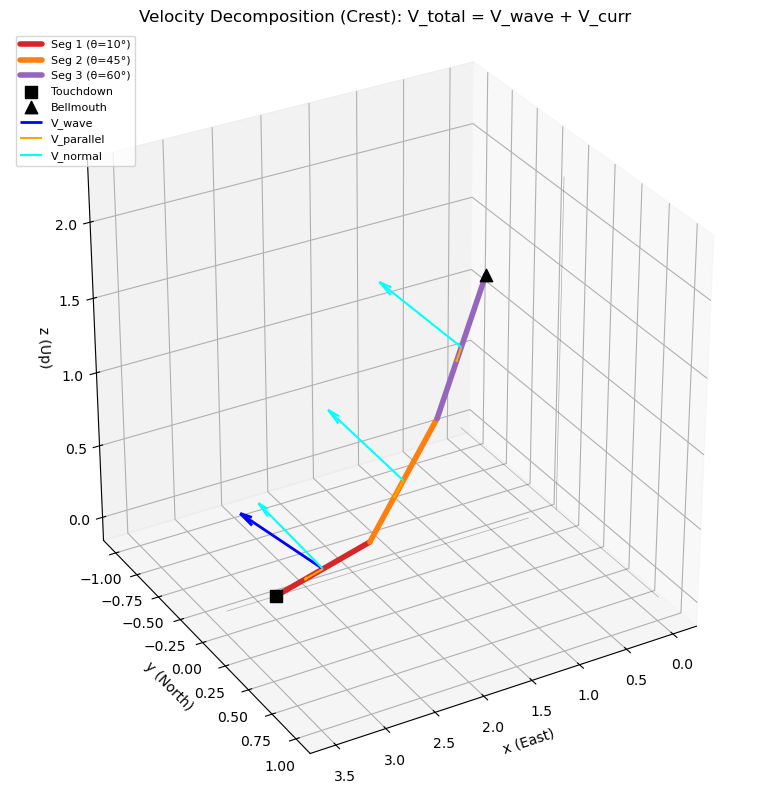

In [107]:
# Plot: velocity decomposition (crest state)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')
plot_scene(ax, segments, touchdown_point, bellmouth, V_wave=V_total_crest)
ax.view_init(elev=30, azim=60)
ax.set_title(f'Velocity Decomposition (Crest): V_total = V_wave + V_curr')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [93]:
# Drag force calculation per segment (crest state, cross-flow drag)
for seg in segments:
    V_n = seg['V_normal_mag']
    if V_n > 0:
        f_per_length = 0.5 * rho * Cd * D * V_n**2  # N/m
        F_mag = f_per_length * seg['length']
        F_drag = F_mag * (seg['V_normal'] / V_n)
    else:
        F_mag, F_drag = 0.0, np.zeros(3)
    
    seg['F_drag'] = F_drag
    seg['F_drag_mag'] = np.linalg.norm(F_drag)
    print(f"Seg {seg['index']}: |F| = {seg['F_drag_mag']:.3f} N")

Seg 1: |F| = 75.825 N
Seg 2: |F| = 78.726 N
Seg 3: |F| = 80.270 N


In [94]:
# Build equivalent beam: straight chord from touchdown to bellmouth
beam_vec = bellmouth - touchdown_point
L_beam = np.linalg.norm(beam_vec)
beam_axis = beam_vec / L_beam

# Project segment midpoints onto beam axis (load application points)
load_positions = []
for seg in segments:
    a_i = np.dot(seg['midpoint'] - touchdown_point, beam_axis)
    load_positions.append(np.clip(a_i, 0, L_beam))
    seg['beam_pos'] = load_positions[-1]

# Project segment edges onto beam axis
edge_positions = [0.0]
for seg in segments:
    ep = np.dot(seg['end'] - touchdown_point, beam_axis)
    edge_positions.append(np.clip(ep, 0, L_beam))

print(f"Beam chord: {L_beam:.3f} m")
print(f"Beam axis: {np.round(beam_axis, 3)}")
print(f"\nLoad positions along beam:")
for i, seg in enumerate(segments):
    print(f"  Seg {seg['index']}: x = {load_positions[i]:.3f} m")
print(f"\nEdge positions: {[round(ep, 3) for ep in edge_positions]}")

Beam chord: 2.803 m
Beam axis: [-0.782 -0.     0.623]

Load positions along beam:
  Seg 1: x = 0.439 m
  Seg 2: x = 1.375 m
  Seg 3: x = 2.337 m

Edge positions: [0.0, np.float64(0.878), np.float64(1.872), np.float64(2.803)]


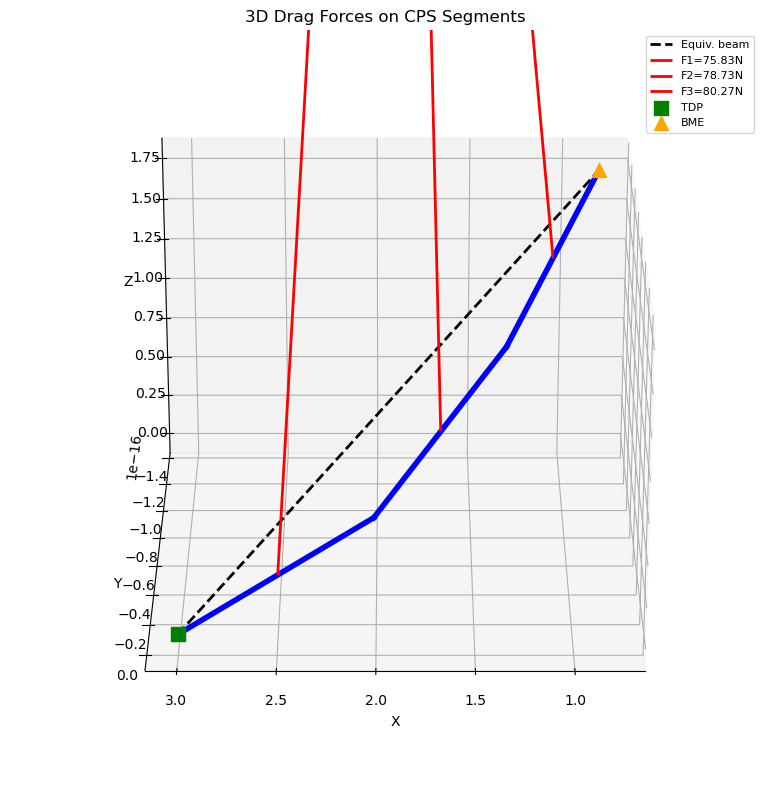

In [110]:
# Plot: 3D forces per segment
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')

# Draw CPS segments
for seg in segments:
    ax.plot3D([seg['start'][0], seg['end'][0]], [seg['start'][1], seg['end'][1]],
              [seg['start'][2], seg['end'][2]], 'b-', linewidth=4)

# Draw equivalent beam chord
ax.plot3D([touchdown_point[0], bellmouth[0]], [touchdown_point[1], bellmouth[1]],
          [touchdown_point[2], bellmouth[2]], 'k--', linewidth=2, label='Equiv. beam')

# Draw forces at segment midpoints
F_max = max(seg['F_drag_mag'] for seg in segments)
F_scale = 0.5 / F_max if F_max > 0 else 1
for seg in segments:
    ax.quiver(*seg['midpoint'], *(seg['F_drag'] * F_scale), color='red', linewidth=2,
              arrow_length_ratio=0.2, label=f'F{seg["index"]}={seg["F_drag_mag"]:.2f}N')

ax.scatter(*touchdown_point, s=100, c='green', marker='s', label='TDP')
ax.scatter(*bellmouth, s=100, c='orange', marker='^', label='BME')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('3D Drag Forces on CPS Segments')
ax.legend(fontsize=8)
ax.view_init(elev=25, azim=90)
plt.tight_layout()
plt.show()

In [96]:
# Project forces onto plane perpendicular to beam axis
# (This is what creates bending in the equivalent beam model)
loads = []  # [(position, magnitude), ...]
for seg in segments:
    F_along = np.dot(seg['F_drag'], beam_axis) * beam_axis
    F_perp = seg['F_drag'] - F_along
    F_perp_mag = np.linalg.norm(F_perp)
    seg['F_perp'] = F_perp
    seg['F_perp_mag'] = F_perp_mag
    loads.append((seg['beam_pos'], F_perp_mag))
    print(f"Seg {seg['index']}: F_perp = {F_perp_mag:.3f} N (3D: {np.round(F_perp, 3)})")

Seg 1: F_perp = 75.804 N (3D: [  2.057 -75.732   2.581])
Seg 2: F_perp = 78.707 N (3D: [  9.655 -77.167  12.115])
Seg 3: F_perp = 79.960 N (3D: [ 11.184 -77.92   14.034])


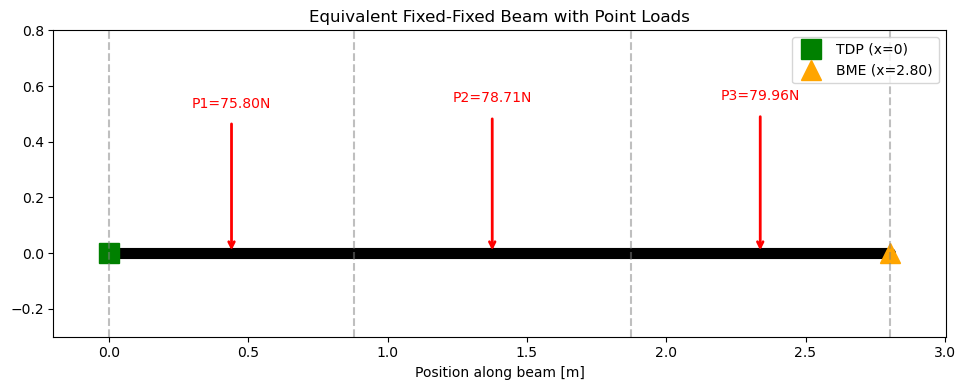

In [97]:
# Plot: 1D beam with translated point loads
fig, ax = plt.subplots(figsize=(12, 4))

# Draw beam
ax.plot([0, L_beam], [0, 0], 'k-', linewidth=8, solid_capstyle='round')
ax.plot(0, 0, 'gs', markersize=15, label='TDP (x=0)')
ax.plot(L_beam, 0, '^', color='orange', markersize=15, label=f'BME (x={L_beam:.2f})')

# Draw forces as arrows
F_max = max(F for (_, F) in loads)
for i, (a, P) in enumerate(loads):
    ax.annotate('', xy=(a, 0), xytext=(a, P/F_max * 0.5),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.text(a, P/F_max * 0.55, f'P{i+1}={P:.2f}N', ha='center', fontsize=10, color='red')

# Draw edge positions
for ep in edge_positions:
    ax.axvline(ep, color='gray', linestyle='--', alpha=0.5)

ax.set_xlim(-0.2, L_beam + 0.2)
ax.set_ylim(-0.3, 0.8)
ax.set_xlabel('Position along beam [m]')
ax.set_title('Equivalent Fixed-Fixed Beam with Point Loads')
ax.legend(loc='upper right')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [98]:
# Fixed-fixed beam solution
def fixed_fixed_beam(loads, L):
    """Returns (M0, ML, R0): end moments at x=0 and x=L, and left shear reaction."""
    M0, ML = 0.0, 0.0
    for (a, P) in loads:
        b = L - a
        M0 += -P * a * b**2 / L**2
        ML += -P * a**2 * b / L**2
    R0 = (ML - M0 + sum(P * (L - a) for (a, P) in loads)) / L
    return M0, ML, R0

def moment_at(x, loads, M0, R0):
    """M(x) for fixed-fixed beam."""
    M = M0 + R0 * x
    for (a, P) in loads:
        if a <= x:
            M -= P * (x - a)
    return M

M0, ML, R0 = fixed_fixed_beam(loads, L_beam)
midspan = L_beam / 2
eval_points = sorted(set(edge_positions + load_positions + [midspan]))

print(f"End moments: M_tdp = {abs(M0):.3f} Nm, M_bme = {abs(ML):.3f} Nm")
print(f"Left reaction: R0 = {R0:.3f} N")
print(f"\nMoments at key points:")
for ep in eval_points:
    print(f"  x = {ep:.2f} m: M = {moment_at(ep, loads, M0, R0):+.3f} Nm")

End moments: M_tdp = 56.909 Nm, M_bme = 57.330 Nm
Left reaction: R0 = 117.141 N

Moments at key points:
  x = 0.00 m: M = -56.909 Nm
  x = 0.44 m: M = -5.462 Nm
  x = 0.88 m: M = +12.693 Nm
  x = 1.38 m: M = +33.230 Nm
  x = 1.40 m: M = +32.252 Nm
  x = 1.87 m: M = +14.664 Nm
  x = 2.34 m: M = -2.727 Nm
  x = 2.80 m: M = -57.330 Nm


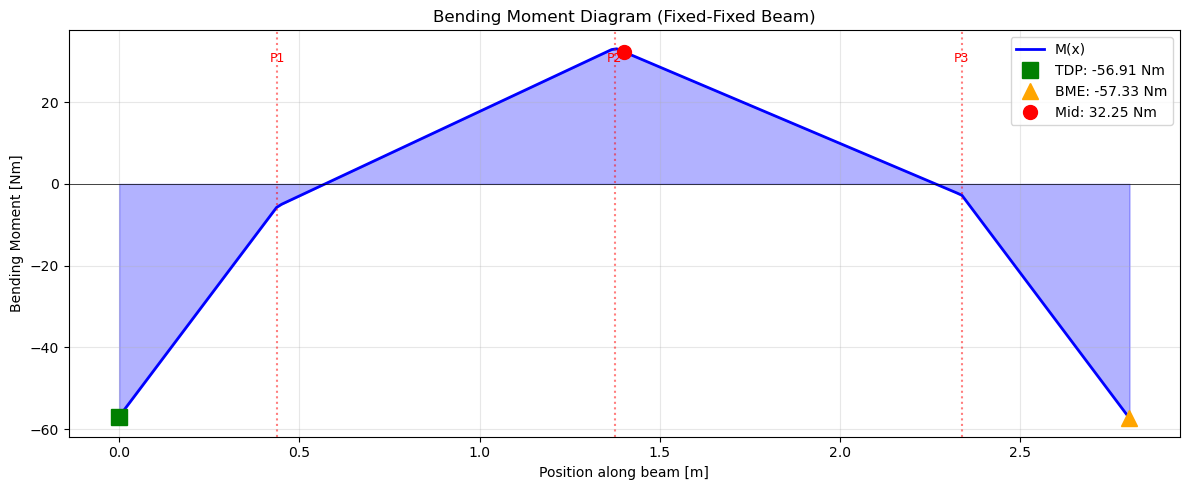

In [99]:
# Plot: Moment diagram
x_plot = np.linspace(0, L_beam, 200)
M_plot = np.array([moment_at(x, loads, M0, R0) for x in x_plot])

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(x_plot, M_plot, alpha=0.3, color='blue')
ax.plot(x_plot, M_plot, 'b-', linewidth=2, label='M(x)')
ax.axhline(0, color='k', linewidth=0.5)

# Mark key points
ax.plot(0, M0, 'gs', markersize=12, label=f'TDP: {M0:.2f} Nm')
ax.plot(L_beam, ML, '^', color='orange', markersize=12, label=f'BME: {ML:.2f} Nm')
ax.plot(midspan, moment_at(midspan, loads, M0, R0), 'ro', markersize=10, 
        label=f'Mid: {moment_at(midspan, loads, M0, R0):.2f} Nm')

# Mark load positions
for i, (a, P) in enumerate(loads):
    ax.axvline(a, color='red', linestyle=':', alpha=0.5)
    ax.text(a, max(M_plot)*0.9, f'P{i+1}', ha='center', color='red', fontsize=9)

ax.set_xlabel('Position along beam [m]')
ax.set_ylabel('Bending Moment [Nm]')
ax.set_title('Bending Moment Diagram (Fixed-Fixed Beam)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

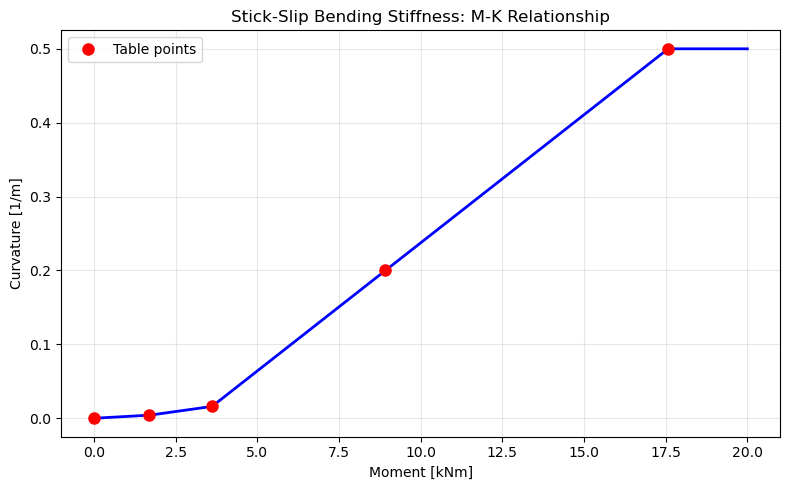

Note: For typical small-scale demo forces, moments << 1 kNm
Max moment in this example: 57.33 Nm = 0.0573 kNm


In [100]:
# Curvature from Stick-Slip bending stiffness (nonlinear M-K relationship)
M_bins = np.array([0, 1.676, 3.612, 8.918, 17.575]) * 1000  # Nm
K_bins = np.array([0, 0.004, 0.016, 0.200, 0.500])          # 1/m

def get_curvature(M):
    return np.interp(abs(M), M_bins, K_bins)

# Plot M-K curve
fig, ax = plt.subplots(figsize=(8, 5))
M_range = np.linspace(0, 20000, 200)
K_range = [get_curvature(m) for m in M_range]
ax.plot(M_range/1000, K_range, 'b-', linewidth=2)
ax.plot(M_bins/1000, K_bins, 'ro', markersize=8, label='Table points')
ax.set_xlabel('Moment [kNm]')
ax.set_ylabel('Curvature [1/m]')
ax.set_title('Stick-Slip Bending Stiffness: M-K Relationship')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("Note: For typical small-scale demo forces, moments << 1 kNm")
print(f"Max moment in this example: {max(abs(M_plot)):.2f} Nm = {max(abs(M_plot))/1000:.4f} kNm")

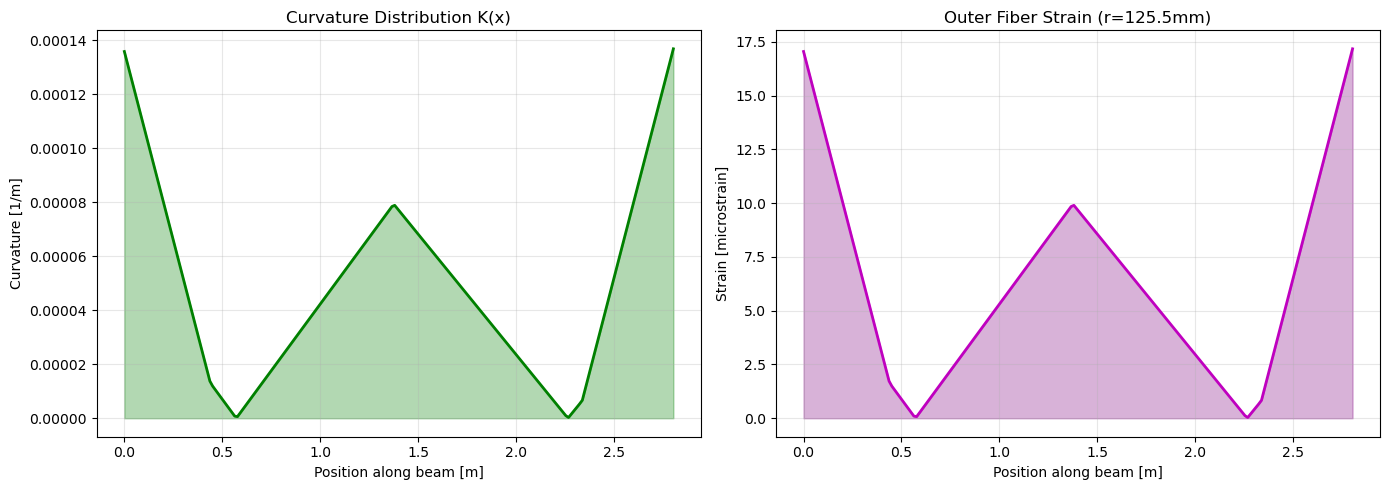

Max curvature: 0.000137 1/m
Max strain: 17.17 microstrain


In [101]:
# Curvature and Strain along beam
r_outer = D / 2  # outer radius for strain calc

K_plot = np.array([get_curvature(m) for m in M_plot])
strain_plot = K_plot * r_outer

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvature
ax = axes[0]
ax.fill_between(x_plot, K_plot, alpha=0.3, color='green')
ax.plot(x_plot, K_plot, 'g-', linewidth=2)
ax.set_xlabel('Position along beam [m]')
ax.set_ylabel('Curvature [1/m]')
ax.set_title('Curvature Distribution K(x)')
ax.grid(True, alpha=0.3)

# Strain
ax = axes[1]
ax.fill_between(x_plot, strain_plot * 1e6, alpha=0.3, color='purple')
ax.plot(x_plot, strain_plot * 1e6, 'm-', linewidth=2)
ax.set_xlabel('Position along beam [m]')
ax.set_ylabel('Strain [microstrain]')
ax.set_title(f'Outer Fiber Strain (r={r_outer*1000:.1f}mm)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Max curvature: {max(K_plot):.6f} 1/m")
print(f"Max strain: {max(strain_plot)*1e6:.2f} microstrain")

In [102]:
# Crest/Trough analysis (matching fls_proxy_ff.py logic)
# Key: wave oscillates (+/-), current is steady
#   Crest:  V_total = +u_w * wave_dir + V_curr
#   Trough: V_total = -u_w * wave_dir + V_curr

def compute_beam_state(wave_sign, segments, beam_axis, L_beam):
    """Compute loads and moments for crest (+1) or trough (-1) wave state."""
    V_total = wave_sign * V_wave + V_curr  # wave flips, current steady
    
    loads_state = []
    for seg in segments:
        # Decompose total velocity into parallel/normal to segment
        V_par = np.dot(V_total, seg['axis']) * seg['axis']
        V_norm = V_total - V_par
        V_n = np.linalg.norm(V_norm)
        
        if V_n > 0:
            F_mag = 0.5 * rho * Cd * D * V_n**2 * seg['length']
            F_drag = F_mag * (V_norm / V_n)
            # Project onto beam-perpendicular plane
            F_perp = F_drag - np.dot(F_drag, beam_axis) * beam_axis
        else:
            F_perp = np.zeros(3)
        loads_state.append((seg['beam_pos'], np.linalg.norm(F_perp)))
    
    M0, ML, R0 = fixed_fixed_beam(loads_state, L_beam)
    M_max = max(abs(moment_at(x, loads_state, M0, R0)) for x in eval_points)
    return abs(M0), abs(ML), M_max, loads_state

# Compute both states
M_tdp_crest, M_bme_crest, M_max_crest, loads_crest = compute_beam_state(+1, segments, beam_axis, L_beam)
M_tdp_trough, M_bme_trough, M_max_trough, loads_trough = compute_beam_state(-1, segments, beam_axis, L_beam)

print(f"V_crest  = +V_wave + V_curr = {np.round(V_wave + V_curr, 3)} m/s")
print(f"V_trough = -V_wave + V_curr = {np.round(-V_wave + V_curr, 3)} m/s\n")

print("Crest (+V_wave):")
print(f"  M_tdp = {M_tdp_crest:.3f} Nm, M_bme = {M_bme_crest:.3f} Nm, M_max = {M_max_crest:.3f} Nm")
print("Trough (-V_wave):")
print(f"  M_tdp = {M_tdp_trough:.3f} Nm, M_bme = {M_bme_trough:.3f} Nm, M_max = {M_max_trough:.3f} Nm")

V_crest  = +V_wave + V_curr = [ 0.2 -0.7  0. ] m/s
V_trough = -V_wave + V_curr = [0.2 0.7 0. ] m/s

Crest (+V_wave):
  M_tdp = 56.909 Nm, M_bme = 57.330 Nm, M_max = 57.330 Nm
Trough (-V_wave):
  M_tdp = 56.909 Nm, M_bme = 57.330 Nm, M_max = 57.330 Nm


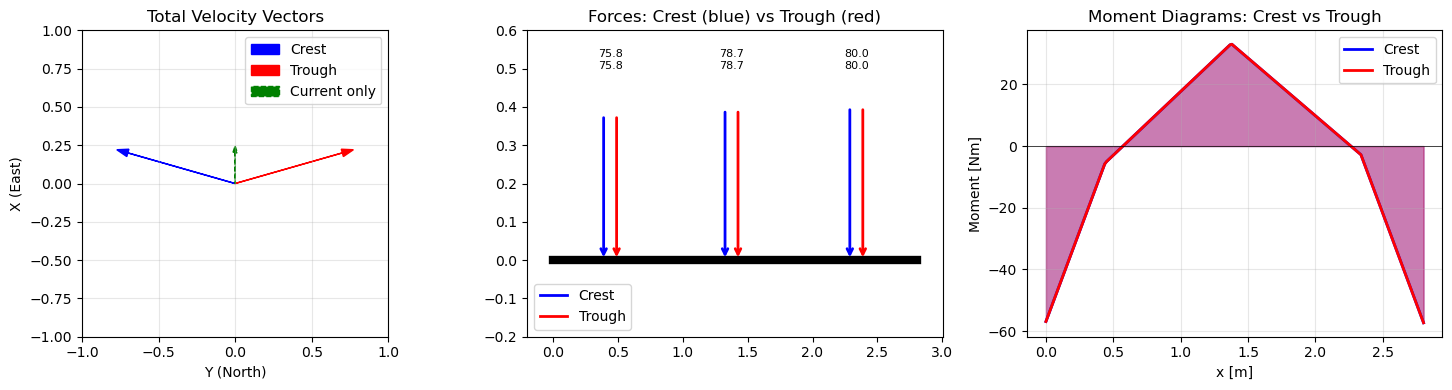

In [103]:
# Plot: Crest vs Trough comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Velocity vectors comparison
ax = axes[0]
V_crest = V_wave + V_curr
V_trough = -V_wave + V_curr
ax.arrow(0, 0, V_crest[1], V_crest[0], head_width=0.05, color='blue', label='Crest')
ax.arrow(0, 0, V_trough[1], V_trough[0], head_width=0.05, color='red', label='Trough')
ax.arrow(0, 0, V_curr[1], V_curr[0], head_width=0.03, color='green', linestyle='--', label='Current only')
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
ax.set_xlabel('Y (North)'); ax.set_ylabel('X (East)')
ax.set_title('Total Velocity Vectors')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_aspect('equal')

# 2. Forces comparison on 1D beam
ax = axes[1]
ax.plot([0, L_beam], [0, 0], 'k-', linewidth=6)
F_max = max(max(F for _, F in loads_crest), max(F for _, F in loads_trough))
for i, ((a, Pc), (_, Pt)) in enumerate(zip(loads_crest, loads_trough)):
    ax.annotate('', xy=(a-0.05, 0), xytext=(a-0.05, Pc/F_max*0.4),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))
    ax.annotate('', xy=(a+0.05, 0), xytext=(a+0.05, Pt/F_max*0.4),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.text(a, 0.5, f'{Pc:.1f}\n{Pt:.1f}', ha='center', fontsize=8)
ax.plot([], [], 'b-', lw=2, label='Crest')
ax.plot([], [], 'r-', lw=2, label='Trough')
ax.set_xlim(-0.2, L_beam+0.2); ax.set_ylim(-0.2, 0.6)
ax.set_title('Forces: Crest (blue) vs Trough (red)'); ax.legend()

# 3. Moment diagrams comparison
ax = axes[2]
M0_c, ML_c, R0_c = fixed_fixed_beam(loads_crest, L_beam)
M0_t, ML_t, R0_t = fixed_fixed_beam(loads_trough, L_beam)
M_crest = [moment_at(x, loads_crest, M0_c, R0_c) for x in x_plot]
M_trough = [moment_at(x, loads_trough, M0_t, R0_t) for x in x_plot]
ax.fill_between(x_plot, M_crest, alpha=0.3, color='blue')
ax.fill_between(x_plot, M_trough, alpha=0.3, color='red')
ax.plot(x_plot, M_crest, 'b-', lw=2, label='Crest')
ax.plot(x_plot, M_trough, 'r-', lw=2, label='Trough')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('x [m]'); ax.set_ylabel('Moment [Nm]')
ax.set_title('Moment Diagrams: Crest vs Trough'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

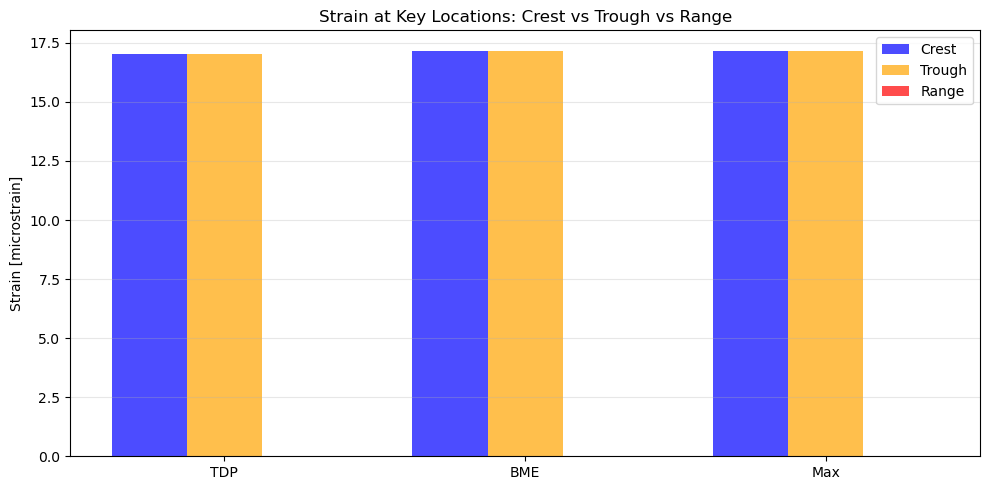

Strain range (max location): 0.00 microstrain


In [104]:
# Strain range calculation (crest - trough)
strain_crest = get_curvature(M_max_crest) * r_outer
strain_trough = get_curvature(M_max_trough) * r_outer
strain_range = abs(strain_crest - strain_trough)

strain_crest_tdp = get_curvature(M_tdp_crest) * r_outer
strain_trough_tdp = get_curvature(M_tdp_trough) * r_outer
strain_range_tdp = abs(strain_crest_tdp - strain_trough_tdp)

strain_crest_bme = get_curvature(M_bme_crest) * r_outer
strain_trough_bme = get_curvature(M_bme_trough) * r_outer
strain_range_bme = abs(strain_crest_bme - strain_trough_bme)

# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))
locs = ['TDP', 'BME', 'Max']
crest_vals = [strain_crest_tdp*1e6, strain_crest_bme*1e6, strain_crest*1e6]
trough_vals = [strain_trough_tdp*1e6, strain_trough_bme*1e6, strain_trough*1e6]
range_vals = [strain_range_tdp*1e6, strain_range_bme*1e6, strain_range*1e6]

x = np.arange(len(locs))
w = 0.25
ax.bar(x - w, crest_vals, w, label='Crest', color='blue', alpha=0.7)
ax.bar(x, trough_vals, w, label='Trough', color='orange', alpha=0.7)
ax.bar(x + w, range_vals, w, label='Range', color='red', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(locs)
ax.set_ylabel('Strain [microstrain]')
ax.set_title('Strain at Key Locations: Crest vs Trough vs Range')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Strain range (max location): {strain_range*1e6:.2f} microstrain")

Wave period Tp = 8.0 s  =>  450 cycles/hour

Strain-based FLS proxy (m=3):
  FLS_proxy (max loc):  1.7502e-59
  FLS_proxy (TDP):      0.0000e+00
  FLS_proxy (BME):      0.0000e+00


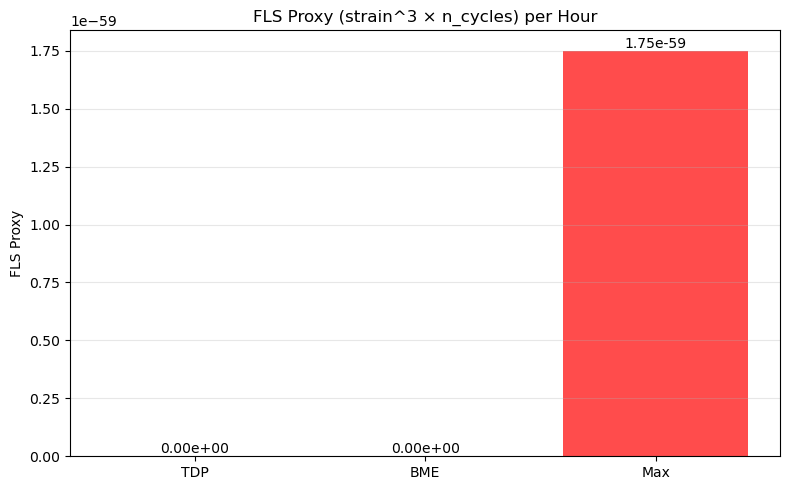

In [105]:
# FLS Proxy calculation (strain-based, matching fls_proxy_ff.py)
m = 3  # SN curve exponent
n_cycles = 3600 / Tp  # cycles per hour (Tp from parameters)

# Strain-based FLS proxy (one count per wave cycle at strain range)
FLS_proxy_max = n_cycles * strain_range**m
FLS_proxy_tdp = n_cycles * strain_range_tdp**m
FLS_proxy_bme = n_cycles * strain_range_bme**m

print(f"Wave period Tp = {Tp} s  =>  {n_cycles:.0f} cycles/hour")
print(f"\nStrain-based FLS proxy (m={m}):")
print(f"  FLS_proxy (max loc):  {FLS_proxy_max:.4e}")
print(f"  FLS_proxy (TDP):      {FLS_proxy_tdp:.4e}")
print(f"  FLS_proxy (BME):      {FLS_proxy_bme:.4e}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
vals = [FLS_proxy_tdp, FLS_proxy_bme, FLS_proxy_max]
colors = ['green', 'orange', 'red']
bars = ax.bar(locs, vals, color=colors, alpha=0.7)
ax.set_ylabel('FLS Proxy')
ax.set_title(f'FLS Proxy (strain^{m} × n_cycles) per Hour')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.2e}', 
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

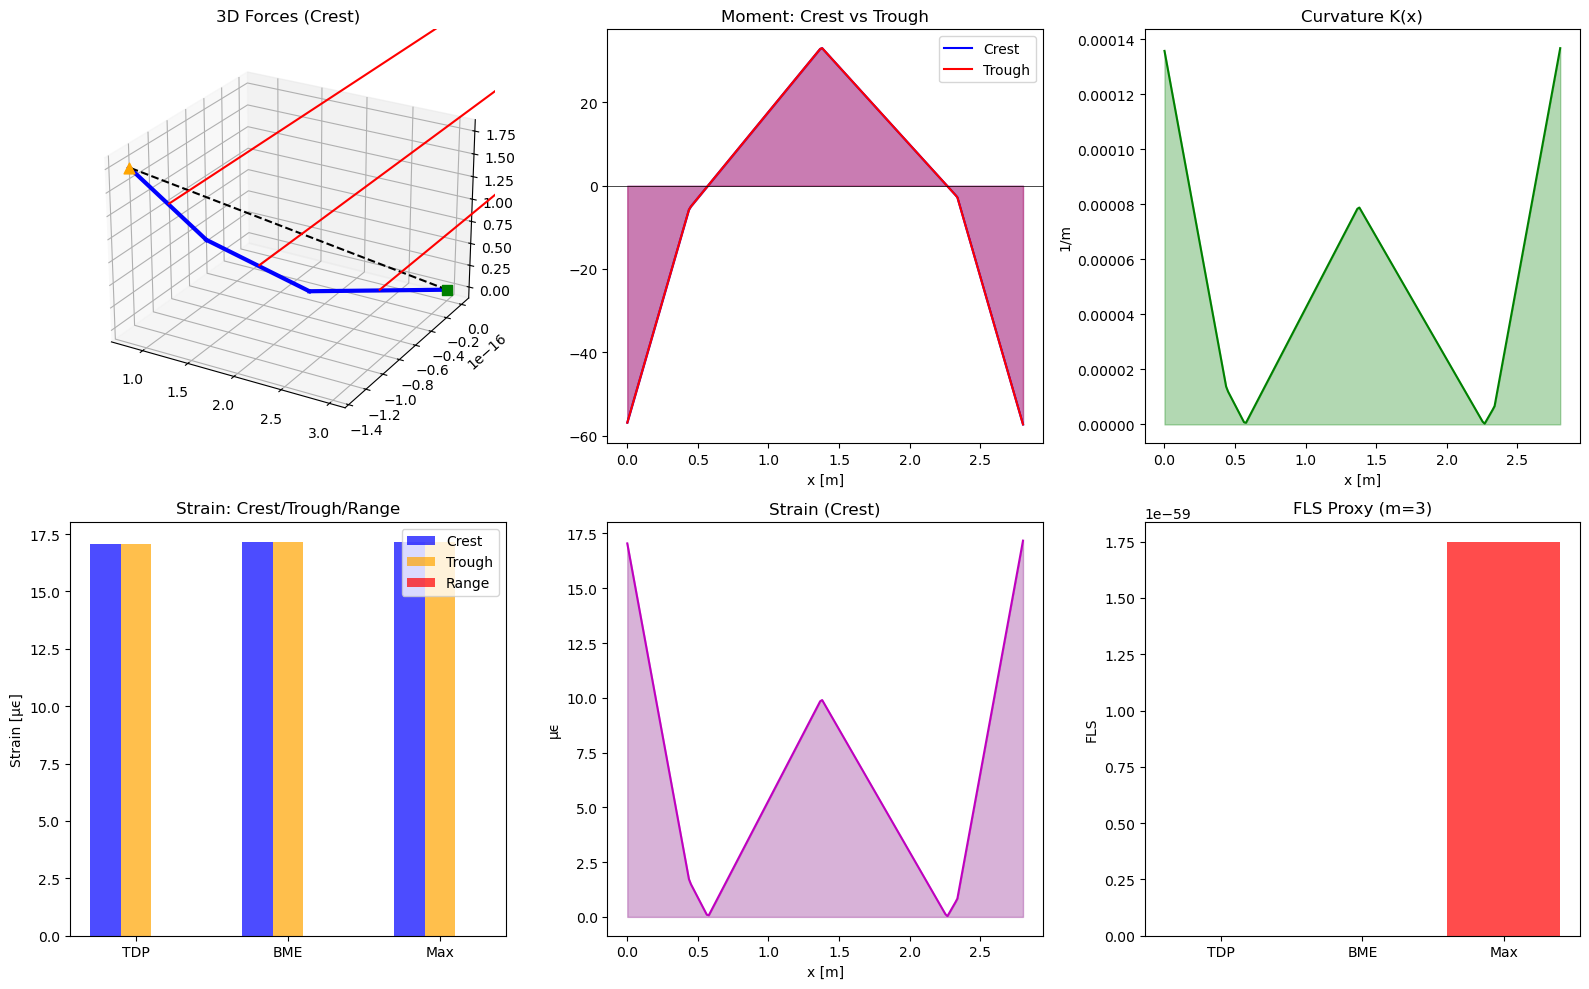


=== Summary ===
D=0.251m, Cd=1.2, rho=1025, Tp=8.0s
u_w=0.7 m/s, u_c=0.2 m/s (collinear)
Max strain range: 0.00 μϵ


In [106]:
# Summary: Full workflow visualization
fig = plt.figure(figsize=(16, 10))

# 1. 3D geometry with forces
ax = fig.add_subplot(2, 3, 1, projection='3d')
for seg in segments:
    ax.plot3D([seg['start'][0], seg['end'][0]], [seg['start'][1], seg['end'][1]],
              [seg['start'][2], seg['end'][2]], 'b-', linewidth=3)
ax.plot3D([touchdown_point[0], bellmouth[0]], [touchdown_point[1], bellmouth[1]],
          [touchdown_point[2], bellmouth[2]], 'k--', linewidth=1.5)
F_max = max(seg['F_drag_mag'] for seg in segments)
for seg in segments:
    ax.quiver(*seg['midpoint'], *(seg['F_drag'] * 0.4/F_max), color='red', linewidth=1.5)
ax.scatter(*touchdown_point, s=60, c='green', marker='s')
ax.scatter(*bellmouth, s=60, c='orange', marker='^')
ax.set_title('3D Forces (Crest)')
ax.view_init(25, -60)

# 2. Crest vs Trough moments
ax = fig.add_subplot(2, 3, 2)
ax.fill_between(x_plot, M_crest, alpha=0.3, color='blue')
ax.fill_between(x_plot, M_trough, alpha=0.3, color='red')
ax.plot(x_plot, M_crest, 'b-', lw=1.5, label='Crest')
ax.plot(x_plot, M_trough, 'r-', lw=1.5, label='Trough')
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Moment: Crest vs Trough'); ax.legend(); ax.set_xlabel('x [m]')

# 3. Curvature
ax = fig.add_subplot(2, 3, 3)
ax.fill_between(x_plot, K_plot, alpha=0.3, color='green')
ax.plot(x_plot, K_plot, 'g-', linewidth=1.5)
ax.set_title('Curvature K(x)'); ax.set_xlabel('x [m]'); ax.set_ylabel('1/m')

# 4. Strain comparison at key locations
ax = fig.add_subplot(2, 3, 4)
x_bar = np.arange(3)
ax.bar(x_bar - 0.2, crest_vals, 0.2, label='Crest', color='blue', alpha=0.7)
ax.bar(x_bar, trough_vals, 0.2, label='Trough', color='orange', alpha=0.7)
ax.bar(x_bar + 0.2, range_vals, 0.2, label='Range', color='red', alpha=0.7)
ax.set_xticks(x_bar); ax.set_xticklabels(locs)
ax.set_ylabel('Strain [μϵ]'); ax.set_title('Strain: Crest/Trough/Range'); ax.legend()

# 5. Strain along beam
ax = fig.add_subplot(2, 3, 5)
ax.fill_between(x_plot, strain_plot*1e6, alpha=0.3, color='purple')
ax.plot(x_plot, strain_plot*1e6, 'm-', linewidth=1.5)
ax.set_title('Strain (Crest)'); ax.set_xlabel('x [m]'); ax.set_ylabel('μϵ')

# 6. FLS proxy comparison
ax = fig.add_subplot(2, 3, 6)
bars = ax.bar(locs, vals, color=colors, alpha=0.7)
ax.set_title(f'FLS Proxy (m={m})'); ax.set_ylabel('FLS')

plt.tight_layout()
plt.show()

print(f"\n=== Summary ===")
print(f"D={D}m, Cd={Cd}, rho={rho}, Tp={Tp}s")
print(f"u_w={u_w} m/s, u_c={u_c} m/s (collinear)")
print(f"Max strain range: {strain_range*1e6:.2f} μϵ")